# Marker Neighborhood Figures

This notebook refines the old `legacy/nonlocal_analysis_ensemble_targeted.ipynb` workflow using the current preprocessed graph files and `organograph.graph.stats` helpers. It loads both datasets, pools matching timepoints across datasets including `day4p5-more` as `day 4.5`, and produces marker-neighborhood figures for the direct-neighbor graph (`k=1`).

## Imports

In [25]:
# Re-run from here if you change the configuration below.
import os
import glob
import pickle
import warnings
from functools import lru_cache
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from organograph.graph.io import load_cell_graph
from organograph.graph.access import graph_get
from organograph.graph.stats import (
    build_weight_matrix_kNN,
    compute_morans_I,
    kNN_marker_composition,
)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "axes.spines.top": True,
    "axes.spines.right": True,
})


def box_on(ax):
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)
    ax.tick_params(top=False, right=False)

## Configuration

By default this uses `graphs_preprocessed`, because that graph folder contains all requested timepoints in the two datasets. `day4p5-more` is included and pooled under `day 4.5`.

In [ ]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in {"notebooks", "notebooks_dev", "legacy"}:
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT.parent / "NicoleData"

DATASETS = ["20250929", "20251201"]
GRAPH_SUBDIR = "graphs_preprocessed"
EXCLUDE_TIMEPOINTS = set()

K_VALUES = [2]
N_PERMS = 199       # Increase to 999 for final figures if runtime is acceptable.
RANDOM_SEED = 7
ROW_STANDARDIZE_W = False
MAX_GRAPHS_PER_TIMEPOINT = None  # e.g. 20 for a quick smoke run; None uses all graphs.

MORAN_ANALYSES = [
    {
        "name": "cell-type markers",
        "sources": ["Serotonin", "Lysozyme"],
        "targets": ["LGR5", "Serotonin", "Lysozyme"],
    },
]

DERIVED_MARKERS = {}

KNN_FOCAL_MARKERS = ["Serotonin", "Lysozyme"]
KNN_TARGET_MARKERS = ["LGR5", "Chroma", "Agr2", "AldoB", "Serotonin", "Lysozyme"]

ENRICHMENT_FOCAL_MARKERS = ["Serotonin", "Lysozyme"]
ENRICHMENT_TARGET_MARKER = "LGR5"
MAX_ENRICHMENT_HOPS = 10

CACHE_DIR = PROJECT_ROOT / "notebooks_dev" / ".cache_marker_neighborhood"
CACHE_DIR.mkdir(exist_ok=True)
USE_CACHE = True

## Load Graph Index

The table below is one row per graph file. Identical timepoints across datasets are intentionally assigned the same `sample_label`, so later plots pool those rows.

In [27]:
def timepoint_to_float(tp):
    return float(str(tp).replace("day", "").replace("p", ".").replace("-more", ""))


def timepoint_label(tp):
    return f"day {timepoint_to_float(tp):g}"


def resolve_graph_path(path_value, dataset, graph_subdir, timepoint, label_uid=None):
    path = Path(str(path_value)) if pd.notna(path_value) else None
    if path is not None and path.exists():
        return path

    candidates = []
    if label_uid:
        candidates.append(DATA_ROOT / dataset / graph_subdir / timepoint / f"{label_uid}.gpickle")
    if path is not None:
        candidates.append(DATA_ROOT / dataset / graph_subdir / timepoint / path.name)

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return path


def discover_graphs(data_root=DATA_ROOT, datasets=DATASETS, graph_subdir=GRAPH_SUBDIR, exclude_timepoints=EXCLUDE_TIMEPOINTS):
    rows = []
    for dataset in datasets:
        root = data_root / dataset / graph_subdir
        if not root.exists():
            warnings.warn(f"Missing graph directory: {root}")
            continue

        for tp_dir in sorted([p for p in root.iterdir() if p.is_dir()]):
            tp = tp_dir.name
            if tp in exclude_timepoints:
                continue

            index_path = tp_dir / "index.csv"
            if index_path.exists():
                df = pd.read_csv(index_path)
                for _, row in df.iterrows():
                    label_uid = row.get("label_uid", Path(str(row.get("graph_path", ""))).stem)
                    graph_path = resolve_graph_path(row.get("graph_path"), dataset, graph_subdir, tp, label_uid)
                    if graph_path is None or not Path(graph_path).exists():
                        continue
                    rows.append({
                        "dataset": dataset,
                        "timepoint": tp,
                        "sample_label": timepoint_label(tp),
                        "time_numeric": timepoint_to_float(tp),
                        "label_uid": label_uid,
                        "graph_path": str(graph_path),
                        "N_cells": row.get("N_cells", np.nan),
                    })
            else:
                for graph_path in sorted(tp_dir.glob("*.gpickle")):
                    rows.append({
                        "dataset": dataset,
                        "timepoint": tp,
                        "sample_label": timepoint_label(tp),
                        "time_numeric": timepoint_to_float(tp),
                        "label_uid": graph_path.stem,
                        "graph_path": str(graph_path),
                        "N_cells": np.nan,
                    })

    table = pd.DataFrame(rows)
    if table.empty:
        raise FileNotFoundError(f"No graph files found under {data_root} for {datasets} / {graph_subdir}")

    table = table.sort_values(["time_numeric", "dataset", "label_uid"]).reset_index(drop=True)
    if MAX_GRAPHS_PER_TIMEPOINT is not None:
        table = (
            table.groupby(["dataset", "timepoint"], group_keys=False, sort=False)
            .head(int(MAX_GRAPHS_PER_TIMEPOINT))
            .reset_index(drop=True)
        )
    return table


graph_table = discover_graphs()
TIMEPOINT_ORDER = (
    graph_table[["sample_label", "time_numeric"]]
    .drop_duplicates()
    .sort_values("time_numeric")["sample_label"]
    .tolist()
)

display(graph_table.groupby(["sample_label", "dataset", "timepoint"]).size().rename("n_graphs").reset_index())
print("Pooled timepoint order:", TIMEPOINT_ORDER)
print(f"Total graphs: {len(graph_table)}")

,sample_label,dataset,timepoint,n_graphs
0,day 2,20250929,day2,280
1,day 2.5,20250929,day2p5,369
2,day 3,20250929,day3,472
3,day 3.5,20250929,day3p5,312
4,day 4,20250929,day4,358
5,day 4.5,20250929,day4p5,108
6,day 4.5,20250929,day4p5-more,449
7,day 4.5,20251201,day4p5,310


Pooled timepoint order: ['day 2', 'day 2.5', 'day 3', 'day 3.5', 'day 4', 'day 4.5']
Total graphs: 2658


## Marker Helpers

Marker names are resolved from each graph. `Chroma`/`ChromA` aliases are handled so the two datasets can be analyzed together.

In [28]:
@lru_cache(maxsize=2048)
def load_graph_cached(graph_path):
    G = load_cell_graph(str(graph_path))
    # The current graph builder uses nodes 0..N-1; this keeps older or unusual files aligned with graph_get.
    if set(G.nodes()) != set(range(G.number_of_nodes())):
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")
    return G


def marker_alias_candidates(marker_name):
    aliases = {
        "ChromA": ["ChromA", "Chroma", "Chromogranin A", "ChromograninA"],
        "Chroma": ["Chroma", "ChromA", "Chromogranin A", "ChromograninA"],
    }
    return aliases.get(marker_name, [marker_name])


def marker_name_to_index(marker_names):
    return {str(name).strip().lower(): i for i, name in enumerate(marker_names)}


def resolve_marker_indices(marker_names, requested):
    name_to_idx = marker_name_to_index(marker_names)
    idx = []
    for marker in requested:
        for alias in marker_alias_candidates(marker):
            key = str(alias).strip().lower()
            if key in name_to_idx and name_to_idx[key] not in idx:
                idx.append(name_to_idx[key])
                break
    return idx


def marker_vector(markers_bin, marker_names, marker_name, derived_markers=DERIVED_MARKERS):
    components = derived_markers.get(marker_name, [marker_name])
    idx = resolve_marker_indices(marker_names, components)
    if len(idx) == 0:
        return None
    return np.any(markers_bin[:, idx].astype(bool), axis=1).astype(float)


def marker_matrix_for_graph(G, requested_markers, derived_markers=DERIVED_MARKERS):
    marker_names = list(G.graph.get("marker_names", []))
    markers_bin = np.asarray(graph_get(G, "markers_bin"))
    cols = []
    for marker in requested_markers:
        v = marker_vector(markers_bin, marker_names, marker, derived_markers=derived_markers)
        if v is None:
            return None
        cols.append(v)
    return np.column_stack(cols).astype(float)


def mean_sem(values, axis=0):
    arr = np.asarray(values, dtype=float)
    mean = np.nanmean(arr, axis=axis)
    count = np.sum(np.isfinite(arr), axis=axis)
    std = np.nanstd(arr, axis=axis, ddof=1)
    sem = np.divide(std, np.sqrt(count), out=np.full_like(mean, np.nan, dtype=float), where=count > 1)
    return mean, sem, count

## Moran's I With Permutation Nulls

For each graph, the notebook builds `W = build_weight_matrix_kNN(G, k=1, row_standardize=False)` and computes cross-Moran's I from source markers to target markers. The null distribution is created by permuting target labels.

In [29]:
def moran_cache_path():
    k_tag = "k" + "-".join(map(str, K_VALUES))
    suffix = f"{GRAPH_SUBDIR}_{k_tag}_celltype_perms{N_PERMS}_seed{RANDOM_SEED}_max{MAX_GRAPHS_PER_TIMEPOINT}.pkl"
    return CACHE_DIR / f"moran_results_rectangular_{suffix}"


def _valid_moran_matrix(X, Y):
    source_var = np.nanvar(X, axis=0) > 0
    target_var = np.nanvar(Y, axis=0) > 0
    return source_var[:, None] & target_var[None, :]


def permutation_test_cross_morans_rectangular(X, W, Y, n_perms=999, seed=None):
    """Permutation test for rectangular source x target cross-Moran grids.

    This mirrors organograph.graph.stats.permutation_test_morans_I but keeps the
    source-marker and target-marker dimensions separate, e.g. 2 x 3.
    """
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    n = X.shape[0]

    I_obs, local_obs, *_ = compute_morans_I(X, W, Y=Y)
    I_perm = np.full((int(n_perms), X.shape[1], Y.shape[1]), np.nan, dtype=float)
    for p in range(int(n_perms)):
        perm_idx = rng.permutation(n)
        I_perm[p], *_ = compute_morans_I(X, W, Y=Y[perm_idx, :])

    p_values = np.nanmean(np.abs(I_perm) >= np.abs(I_obs)[None, :, :], axis=0)
    return I_obs, local_obs, I_perm, p_values


def compute_moran_results(graph_table, analyses=MORAN_ANALYSES, k_values=K_VALUES, n_perms=N_PERMS, seed=RANDOM_SEED):
    cache_path = moran_cache_path()
    if USE_CACHE and cache_path.exists():
        print(f"Loading cached Moran results: {cache_path}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    rng = np.random.default_rng(seed)
    rows = []

    for _, rec in tqdm(graph_table.iterrows(), total=len(graph_table), desc="Moran graphs"):
        G = load_graph_cached(rec.graph_path)
        if G.number_of_nodes() < 3 or G.number_of_edges() == 0:
            continue

        for k in k_values:
            W, _nodes = build_weight_matrix_kNN(G, k=int(k), row_standardize=ROW_STANDARDIZE_W)
            if not np.isfinite(W).all() or W.sum() == 0:
                continue

            for analysis in analyses:
                X = marker_matrix_for_graph(G, analysis["sources"])
                Y = marker_matrix_for_graph(G, analysis["targets"])
                if X is None or Y is None:
                    continue

                valid = _valid_moran_matrix(X, Y)
                if not np.any(valid):
                    continue

                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore", RuntimeWarning)
                        I_obs, _local, I_perm, p_values = permutation_test_cross_morans_rectangular(
                            X,
                            W,
                            Y,
                            n_perms=int(n_perms),
                            seed=int(rng.integers(0, 2**31 - 1)),
                        )
                except Exception as err:
                    warnings.warn(f"Moran failed for {rec.label_uid} k={k} {analysis['name']}: {err}")
                    continue

                I_obs = np.asarray(I_obs, dtype=float)
                I_perm = np.asarray(I_perm, dtype=float)
                p_values = np.asarray(p_values, dtype=float)
                I_obs[~valid] = np.nan
                I_perm[:, ~valid] = np.nan
                p_values[~valid] = np.nan

                for i, source in enumerate(analysis["sources"]):
                    for j, target in enumerate(analysis["targets"]):
                        obs = I_obs[i, j]
                        if not np.isfinite(obs):
                            continue
                        rows.append({
                            "analysis": analysis["name"],
                            "k": int(k),
                            "dataset": rec.dataset,
                            "timepoint": rec.timepoint,
                            "sample_label": rec.sample_label,
                            "time_numeric": float(rec.time_numeric),
                            "label_uid": rec.label_uid,
                            "source": source,
                            "target": target,
                            "I_obs": float(obs),
                            "I_perm": I_perm[:, i, j].astype(float),
                            "p_value": float(p_values[i, j]) if np.isfinite(p_values[i, j]) else np.nan,
                        })

    result = pd.DataFrame(rows)
    if USE_CACHE:
        with open(cache_path, "wb") as f:
            pickle.dump(result, f)
        print(f"Saved Moran cache: {cache_path}")
    return result

moran_df = compute_moran_results(graph_table)
display(moran_df.head())
if moran_df.empty:
    print("No Moran results were computed. Check marker availability and graph connectivity.")
else:
    display(moran_df.groupby(["analysis", "k", "sample_label", "source", "target"]).size().rename("n_graphs").reset_index().head(20))

Moran graphs:   0%|          | 0/2658 [00:00<?, ?it/s]

Saved Moran cache: /home/fmoller/Projects/LearningOrganoids/OrganoGraph/notebooks_dev/.cache_marker_neighborhood/moran_results_rectangular_graphs_preprocessed_coexpfixed_k2_celltype_perms199_seed7_maxNone.pkl


,analysis,k,dataset,timepoint,sample_label,time_numeric,label_uid,source,target,I_obs,I_perm,p_value
0,cell-type markers,2,20250929,day2,day 2,2.0,day2_A01_4,Lysozyme,Lysozyme,-0.049489,"[-0.045561665357423405, 0.02120974076983504, 0...",0.301508
1,cell-type markers,2,20250929,day2,day 2,2.0,day2_A02_38,Lysozyme,LGR5,0.117261,"[0.09756097560975616, -0.07973733583489684, -0...",0.030151
2,cell-type markers,2,20250929,day2,day 2,2.0,day2_A02_38,Lysozyme,Lysozyme,-0.054409,"[0.03752345215759852, 0.017823639774859297, 0....",0.361809
3,cell-type markers,2,20250929,day2,day 2,2.0,day2_A04_55,Serotonin,LGR5,0.068519,"[-0.03333333333333334, -0.043518518518518526, ...",0.261307
4,cell-type markers,2,20250929,day2,day 2,2.0,day2_A04_55,Serotonin,Serotonin,-0.103704,"[0.008333333333333335, 0.01851851851851852, 0....",0.075377


,analysis,k,sample_label,source,target,n_graphs
0,cell-type markers,2,day 2,Lysozyme,LGR5,1
1,cell-type markers,2,day 2,Lysozyme,Lysozyme,2
2,cell-type markers,2,day 2,Serotonin,LGR5,1
3,cell-type markers,2,day 2,Serotonin,Serotonin,1
4,cell-type markers,2,day 2.5,Lysozyme,LGR5,12
5,cell-type markers,2,day 2.5,Lysozyme,Lysozyme,21
6,cell-type markers,2,day 2.5,Lysozyme,Serotonin,1
7,cell-type markers,2,day 2.5,Serotonin,LGR5,8
8,cell-type markers,2,day 2.5,Serotonin,Lysozyme,1
9,cell-type markers,2,day 2.5,Serotonin,Serotonin,11


In [30]:
def summarize_moran_for_plot(moran_df, analysis, k, sources, targets, lower_q=2.5, upper_q=97.5):
    rows = []
    df = moran_df[(moran_df["analysis"] == analysis) & (moran_df["k"] == int(k))]
    for source in sources:
        for target in targets:
            for sample_label in TIMEPOINT_ORDER:
                sub = df[(df["source"] == source) & (df["target"] == target) & (df["sample_label"] == sample_label)]
                if sub.empty:
                    rows.append({
                        "source": source,
                        "target": target,
                        "sample_label": sample_label,
                        "time_numeric": np.nan,
                        "obs_mean": np.nan,
                        "obs_sem": np.nan,
                        "null_mean": np.nan,
                        "null_low": np.nan,
                        "null_high": np.nan,
                        "n_graphs": 0,
                    })
                    continue
                obs_mean, obs_sem, n_graphs = mean_sem(sub["I_obs"].to_numpy(dtype=float), axis=0)
                perm_parts = [np.asarray(x, dtype=float) for x in sub["I_perm"]]
                perm_flat = np.concatenate(perm_parts) if len(perm_parts) else np.asarray([], dtype=float)
                perm_flat = perm_flat[np.isfinite(perm_flat)]
                rows.append({
                    "source": source,
                    "target": target,
                    "sample_label": sample_label,
                    "time_numeric": float(sub["time_numeric"].iloc[0]),
                    "obs_mean": float(obs_mean),
                    "obs_sem": float(obs_sem) if np.isfinite(obs_sem) else np.nan,
                    "null_mean": float(np.nanmean(perm_flat)) if perm_flat.size else np.nan,
                    "null_low": float(np.nanpercentile(perm_flat, lower_q)) if perm_flat.size else np.nan,
                    "null_high": float(np.nanpercentile(perm_flat, upper_q)) if perm_flat.size else np.nan,
                    "n_graphs": int(n_graphs),
                })
    return pd.DataFrame(rows)


def plot_moran_grid(moran_df, analysis_spec, k, lower_q=2.5, upper_q=97.5):
    sources = list(analysis_spec["sources"])
    targets = list(analysis_spec["targets"])
    summary = summarize_moran_for_plot(moran_df, analysis_spec["name"], k, sources, targets, lower_q, upper_q)

    n_rows = len(targets)
    n_cols = len(sources)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.35 * n_cols, 1.65 * n_rows),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.asarray(axes).reshape(n_rows, n_cols)
    x = np.arange(len(TIMEPOINT_ORDER))

    for col, source in enumerate(sources):
        for row, target in enumerate(targets):
            ax = axes[row, col]
            s = summary[(summary["source"] == source) & (summary["target"] == target)].set_index("sample_label").reindex(TIMEPOINT_ORDER).reset_index()

            obs = s["obs_mean"].to_numpy(dtype=float)
            obs_sem = s["obs_sem"].to_numpy(dtype=float)
            null_mean = s["null_mean"].to_numpy(dtype=float)
            null_low = s["null_low"].to_numpy(dtype=float)
            null_high = s["null_high"].to_numpy(dtype=float)

            ax.fill_between(x, null_low, null_high, color="0.75", alpha=0.55, label="Null 95%")
            ax.plot(x, null_mean, color="0.35", linestyle="--", linewidth=1.0, label="Null mean")
            ax.errorbar(x, obs, yerr=obs_sem, color="tab:red", marker="o", linewidth=1.8, capsize=2, label="Observed")
            ax.axhline(0, color="0.2", linewidth=0.8, linestyle=":")
            ax.grid(alpha=0.3)
            box_on(ax)
            ax.set_title(f"Source: {source}\nTarget: {target}", fontsize=8)
            ax.set_xticks(x)
            ax.set_xticklabels(TIMEPOINT_ORDER, rotation=45, ha="right")
            if col == 0:
                ax.set_ylabel("Moran's I")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=3, frameon=False)
    fig.suptitle(f"Moran's I vs time | {analysis_spec['name']} | W k={k}", fontsize=11, fontweight="bold")
    plt.show()
    return fig, axes, summary

### Moran's I Figures

/home/fmoller/miniforge3/envs/SphericalHarmonics/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


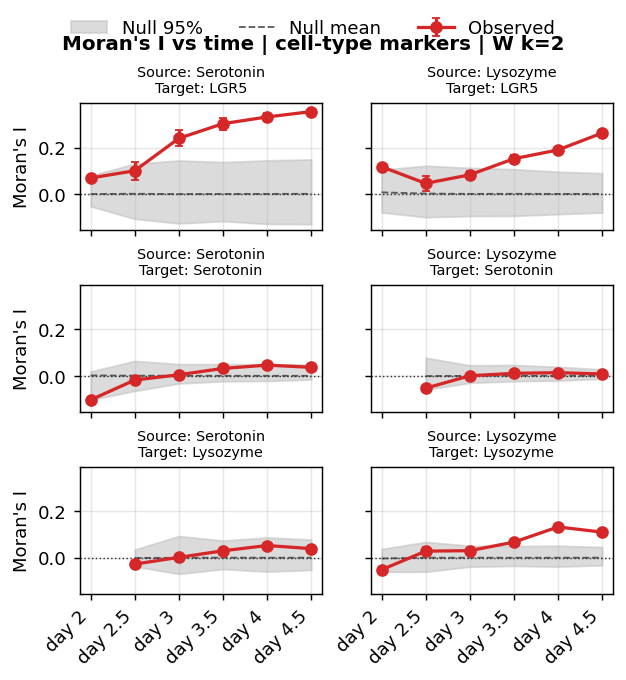

In [31]:
moran_summaries = {}
for k in K_VALUES:
    for analysis in MORAN_ANALYSES:
        fig, axes, summary = plot_moran_grid(moran_df, analysis, k=k)
        moran_summaries[(analysis["name"], k)] = summary

## Fractional kNN Marker Composition

For each focal cell positive for Serotonin or Lysozyme, `kNN_marker_composition` computes the fraction of its `k` nearest graph neighbors that are positive for each target marker. The bars below summarize organoid-level averages across graphs within each pooled timepoint.

In [32]:
def knn_cache_path():
    k_tag = "k" + "-".join(map(str, K_VALUES))
    suffix = f"{GRAPH_SUBDIR}_{k_tag}_celltype_seed{RANDOM_SEED}_max{MAX_GRAPHS_PER_TIMEPOINT}.pkl"
    return CACHE_DIR / f"knn_results_{suffix}"


def compute_knn_results(graph_table, focal_markers=KNN_FOCAL_MARKERS, target_markers=KNN_TARGET_MARKERS, k_values=K_VALUES):
    cache_path = knn_cache_path()
    if USE_CACHE and cache_path.exists():
        print(f"Loading cached kNN results: {cache_path}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    all_markers = []
    for marker in list(focal_markers) + list(target_markers):
        if marker not in all_markers:
            all_markers.append(marker)

    rows = []
    for _, rec in tqdm(graph_table.iterrows(), total=len(graph_table), desc="kNN graphs"):
        G = load_graph_cached(rec.graph_path)
        X = marker_matrix_for_graph(G, all_markers)
        if X is None:
            continue

        marker_to_idx = {m: i for i, m in enumerate(all_markers)}
        for k in k_values:
            for focal in focal_markers:
                focal_idx = marker_to_idx[focal]
                if np.nansum(X[:, focal_idx]) == 0:
                    continue
                try:
                    avg_comp, std_comp, sem_comp, comp_accum = kNN_marker_composition(
                        G,
                        X.astype(int),
                        focal_marker_idx=focal_idx,
                        k=int(k),
                    )
                except Exception as err:
                    warnings.warn(f"kNN failed for {rec.label_uid} focal={focal} k={k}: {err}")
                    continue

                for target in target_markers:
                    target_idx = marker_to_idx[target]
                    rows.append({
                        "k": int(k),
                        "dataset": rec.dataset,
                        "timepoint": rec.timepoint,
                        "sample_label": rec.sample_label,
                        "time_numeric": float(rec.time_numeric),
                        "label_uid": rec.label_uid,
                        "focal": focal,
                        "target": target,
                        "fraction": float(avg_comp[target_idx]),
                        "n_focal_cells": int(comp_accum.shape[0]),
                    })

    result = pd.DataFrame(rows)
    if USE_CACHE:
        with open(cache_path, "wb") as f:
            pickle.dump(result, f)
        print(f"Saved kNN cache: {cache_path}")
    return result


knn_df = compute_knn_results(graph_table)
display(knn_df.head())
display(knn_df.groupby(["k", "sample_label", "focal"]).size().rename("n_values").reset_index())

kNN graphs:   0%|          | 0/2658 [00:00<?, ?it/s]

Saved kNN cache: /home/fmoller/Projects/LearningOrganoids/OrganoGraph/notebooks_dev/.cache_marker_neighborhood/knn_results_graphs_preprocessed_coexpfixed_k2_celltype_seed7_maxNone.pkl


,k,dataset,timepoint,sample_label,time_numeric,label_uid,focal,target,fraction,n_focal_cells
0,2,20250929,day2,day 2,2.0,day2_A01_4,Lysozyme,LGR5,0.0,1
1,2,20250929,day2,day 2,2.0,day2_A01_4,Lysozyme,Chroma,0.0,1
2,2,20250929,day2,day 2,2.0,day2_A01_4,Lysozyme,Agr2,0.5,1
3,2,20250929,day2,day 2,2.0,day2_A01_4,Lysozyme,AldoB,0.0,1
4,2,20250929,day2,day 2,2.0,day2_A01_4,Lysozyme,Serotonin,0.0,1


,k,sample_label,focal,n_values
0,2,day 2,Lysozyme,18
1,2,day 2,Serotonin,6
2,2,day 2.5,Lysozyme,126
3,2,day 2.5,Serotonin,66
4,2,day 3,Lysozyme,786
5,2,day 3,Serotonin,312
6,2,day 3.5,Lysozyme,942
7,2,day 3.5,Serotonin,522
8,2,day 4,Lysozyme,1500
9,2,day 4,Serotonin,1056


In [33]:
def summarize_knn(knn_df, k, focal_markers=KNN_FOCAL_MARKERS, target_markers=KNN_TARGET_MARKERS):
    rows = []
    df = knn_df[knn_df["k"] == int(k)]
    for sample_label in TIMEPOINT_ORDER:
        for focal in focal_markers:
            for target in target_markers:
                sub = df[(df["sample_label"] == sample_label) & (df["focal"] == focal) & (df["target"] == target)]
                vals = sub["fraction"].to_numpy(dtype=float)
                if vals.size == 0:
                    mean = sem = np.nan
                    n = 0
                else:
                    mean, sem, n = mean_sem(vals, axis=0)
                rows.append({
                    "sample_label": sample_label,
                    "focal": focal,
                    "target": target,
                    "mean": float(mean) if np.isfinite(mean) else np.nan,
                    "sem": float(sem) if np.isfinite(sem) else np.nan,
                    "n_graphs": int(n),
                })
    return pd.DataFrame(rows)


def plot_knn_bars(knn_df, k, focal_markers=KNN_FOCAL_MARKERS, target_markers=KNN_TARGET_MARKERS):
    summary = summarize_knn(knn_df, k, focal_markers=focal_markers, target_markers=target_markers)

    n_tp = len(TIMEPOINT_ORDER)
    ncols = min(3, n_tp)
    nrows = int(np.ceil(n_tp / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 2.45 * nrows), sharey=True, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    x = np.arange(len(target_markers))
    width = 0.78 / max(1, len(focal_markers))
    colors = dict(zip(focal_markers, plt.get_cmap("tab10").colors[:len(focal_markers)]))

    for ax, sample_label in zip(axes, TIMEPOINT_ORDER):
        for i, focal in enumerate(focal_markers):
            sub = (
                summary[(summary["sample_label"] == sample_label) & (summary["focal"] == focal)]
                .set_index("target")
                .reindex(target_markers)
            )
            xpos = x + (i - (len(focal_markers) - 1) / 2) * width
            ax.bar(
                xpos,
                sub["mean"].to_numpy(dtype=float),
                yerr=sub["sem"].to_numpy(dtype=float),
                width=width,
                color=colors[focal],
                alpha=0.88,
                capsize=2,
                label=focal,
            )
        ax.set_title(sample_label, fontsize=10, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(target_markers, rotation=45, ha="right")
        ax.set_ylim(0, 1)
        ax.grid(axis="y", alpha=0.3)
        box_on(ax)
        ax.set_ylabel("fraction of kNN positive")

    for ax in axes[n_tp:]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=len(focal_markers), frameon=False)
    fig.suptitle(f"Fractional kNN marker composition | k={k}", fontsize=11, fontweight="bold")
    plt.show()
    return fig, axes, summary

### kNN Figures

/home/fmoller/miniforge3/envs/SphericalHarmonics/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


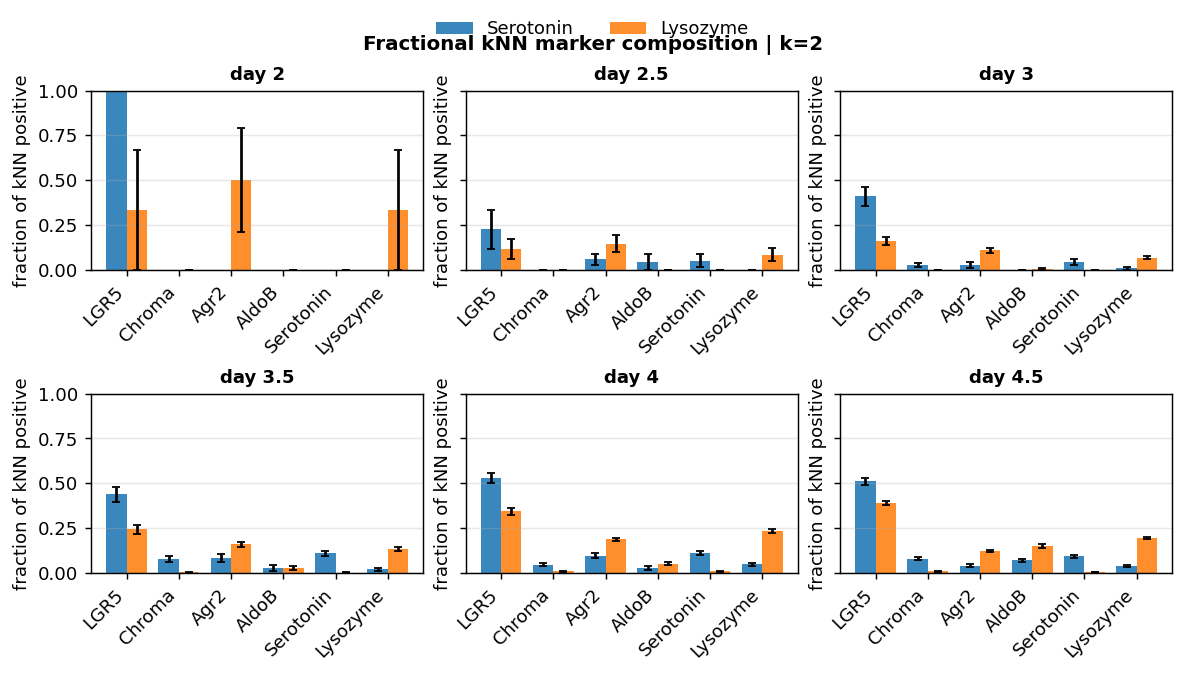

In [34]:
knn_summaries = {}
for k in K_VALUES:
    fig, axes, summary = plot_knn_bars(knn_df, k=k)
    knn_summaries[k] = summary

## LGR5 Enrichment Around Marker-Positive Cells

For each `Serotonin+` or `Lysozyme+` source cell, distances are measured in integer graph hops. The LGR5 fraction at hop `d` is pooled across all source-centered shells within one organoid and normalized by the global LGR5 fraction in that organoid. Curves show the mean enrichment across organoids within each pooled timepoint. Hop `0` is omitted because it represents same-cell coexpression rather than neighborhood enrichment.


Loading cached enrichment results: /home/fmoller/Projects/LearningOrganoids/OrganoGraph/notebooks_dev/.cache_marker_neighborhood/lgr5_enrichment_graphs_preprocessed_coexpfixed_LGR5_hops10_seed7_maxNone.pkl


,dataset,timepoint,sample_label,time_numeric,label_uid,source,target,enrichment,total_counts
0,20250929,day2,day 2,2.0,day2_A02_38,Lysozyme,LGR5,"[0.0, 2.1, 0.7000000000000001, 0.0, nan, nan, ...","[1.0, 5.0, 5.0, 3.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,20250929,day2,day 2,2.0,day2_A04_55,Serotonin,LGR5,"[0.0, 1.2571428571428573, 0.9428571428571428, ...","[1.0, 5.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,20250929,day2p5,day 2.5,2.5,day2p5_A01_111,Lysozyme,LGR5,"[0.0, 0.0, 0.0, 0.5396825396825397, 1.59375, 2...","[4.0, 21.0, 51.0, 63.0, 64.0, 50.0, 19.0, 0.0,..."
3,20250929,day2p5,day 2.5,2.5,day2p5_A01_136,Lysozyme,LGR5,"[0.0, 0.673170731707317, 1.1205128205128205, 1...","[14.0, 82.0, 156.0, 185.0, 158.0, 49.0, 0.0, 0..."
4,20250929,day2p5,day 2.5,2.5,day2p5_A01_25,Serotonin,LGR5,"[0.0, 0.0, 2.4999999999999996, 1.7307692307692...","[1.0, 5.0, 9.0, 13.0, 10.0, 7.0, 0.0, 0.0, 0.0..."


/tmp/ipykernel_3343081/1573173009.py:56: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=axis)
/home/fmoller/miniforge3/envs/SphericalHarmonics/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


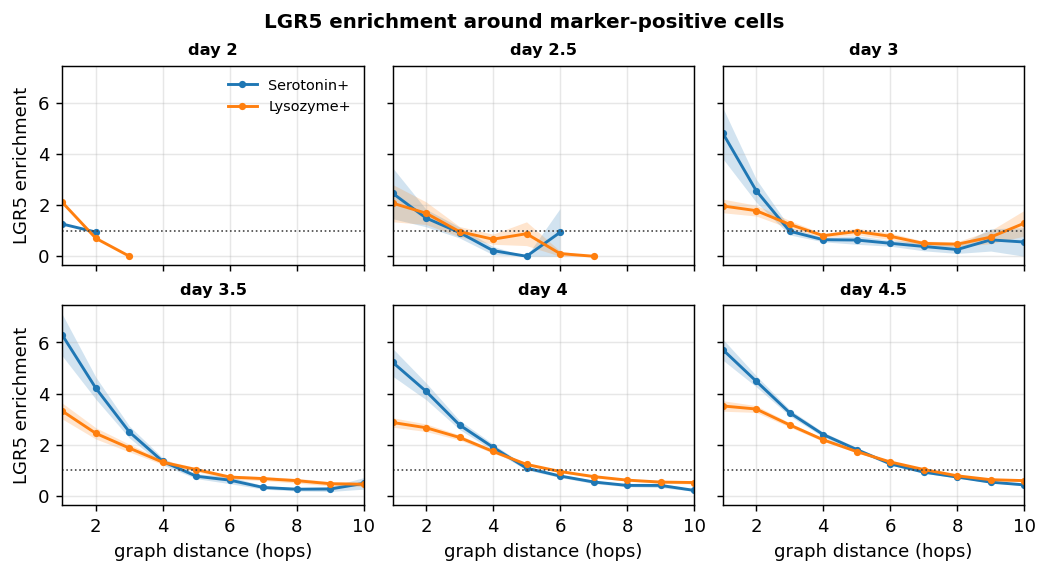

In [35]:
def enrichment_cache_path():
    suffix = f"{GRAPH_SUBDIR}_LGR5_hops{MAX_ENRICHMENT_HOPS}_seed{RANDOM_SEED}_max{MAX_GRAPHS_PER_TIMEPOINT}.pkl"
    return CACHE_DIR / f"lgr5_enrichment_{suffix}"


def graph_hop_enrichment_for_source(G, source_marker, target_marker="LGR5", max_hops=10):
    marker_names = list(G.graph.get("marker_names", []))
    markers_bin = np.asarray(graph_get(G, "markers_bin"))
    source = marker_vector(markers_bin, marker_names, source_marker)
    target = marker_vector(markers_bin, marker_names, target_marker)
    if source is None or target is None:
        return None

    source_nodes = np.flatnonzero(source.astype(bool))
    if source_nodes.size == 0:
        return None
    global_target_fraction = float(np.nanmean(target))
    if not np.isfinite(global_target_fraction) or global_target_fraction <= 0:
        return None

    total_counts = np.zeros(int(max_hops) + 1, dtype=float)
    target_counts = np.zeros(int(max_hops) + 1, dtype=float)
    for node in source_nodes:
        lengths = nx.single_source_shortest_path_length(G, int(node), cutoff=int(max_hops))
        for nb, dist in lengths.items():
            d = int(dist)
            if 0 <= d <= int(max_hops):
                total_counts[d] += 1.0
                target_counts[d] += target[int(nb)]

    local_fraction = np.divide(
        target_counts,
        total_counts,
        out=np.full_like(target_counts, np.nan, dtype=float),
        where=total_counts > 0,
    )
    enrichment = local_fraction / global_target_fraction
    return enrichment, total_counts


def compute_lgr5_enrichment_results(graph_table, focal_markers=ENRICHMENT_FOCAL_MARKERS, target_marker=ENRICHMENT_TARGET_MARKER, max_hops=MAX_ENRICHMENT_HOPS):
    cache_path = enrichment_cache_path()
    if USE_CACHE and cache_path.exists():
        print(f"Loading cached enrichment results: {cache_path}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    rows = []
    for _, rec in tqdm(graph_table.iterrows(), total=len(graph_table), desc="LGR5 enrichment graphs"):
        G = load_graph_cached(rec.graph_path)
        if G.number_of_nodes() < 3 or G.number_of_edges() == 0:
            continue
        for source in focal_markers:
            out = graph_hop_enrichment_for_source(G, source, target_marker=target_marker, max_hops=max_hops)
            if out is None:
                continue
            enrichment, total_counts = out
            rows.append({
                "dataset": rec.dataset,
                "timepoint": rec.timepoint,
                "sample_label": rec.sample_label,
                "time_numeric": float(rec.time_numeric),
                "label_uid": rec.label_uid,
                "source": source,
                "target": target_marker,
                "enrichment": enrichment.astype(float),
                "total_counts": total_counts.astype(float),
            })

    result = pd.DataFrame(rows)
    if USE_CACHE:
        with open(cache_path, "wb") as f:
            pickle.dump(result, f)
        print(f"Saved enrichment cache: {cache_path}")
    return result


def summarize_lgr5_enrichment(enrichment_df, focal_markers=ENRICHMENT_FOCAL_MARKERS, max_hops=MAX_ENRICHMENT_HOPS):
    rows = []
    for sample_label in TIMEPOINT_ORDER:
        for source in focal_markers:
            sub = enrichment_df[(enrichment_df["sample_label"] == sample_label) & (enrichment_df["source"] == source)]
            if sub.empty:
                mean = sem = np.full(int(max_hops) + 1, np.nan, dtype=float)
                n = np.zeros(int(max_hops) + 1, dtype=int)
            else:
                curves = np.stack(sub["enrichment"].to_numpy(), axis=0).astype(float)
                mean, sem, n = mean_sem(curves, axis=0)
            for d in range(int(max_hops) + 1):
                rows.append({
                    "sample_label": sample_label,
                    "source": source,
                    "distance_hops": d,
                    "mean": float(mean[d]) if np.isfinite(mean[d]) else np.nan,
                    "sem": float(sem[d]) if np.isfinite(sem[d]) else np.nan,
                    "n_graphs": int(n[d]),
                })
    return pd.DataFrame(rows)


def plot_lgr5_enrichment(enrichment_df, focal_markers=ENRICHMENT_FOCAL_MARKERS, max_hops=MAX_ENRICHMENT_HOPS, min_hop=1):
    summary = summarize_lgr5_enrichment(enrichment_df, focal_markers=focal_markers, max_hops=max_hops)
    n_timepoints = len(TIMEPOINT_ORDER)
    ncols = min(3, n_timepoints)
    nrows = int(np.ceil(n_timepoints / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(2.65 * ncols, 2.15 * nrows),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()
    colors = dict(zip(focal_markers, plt.get_cmap("tab10").colors[:len(focal_markers)]))

    for i, (ax, sample_label) in enumerate(zip(axes, TIMEPOINT_ORDER)):
        for source in focal_markers:
            sub = summary[
                (summary["source"] == source)
                & (summary["sample_label"] == sample_label)
                & (summary["distance_hops"] >= int(min_hop))
            ].sort_values("distance_hops")
            if sub.empty:
                continue

            x = sub["distance_hops"].to_numpy(dtype=float)
            y = sub["mean"].to_numpy(dtype=float)
            se = sub["sem"].to_numpy(dtype=float)
            color = colors[source]
            ax.plot(x, y, marker="o", linewidth=1.6, markersize=3.0, color=color, label=f"{source}+")
            ax.fill_between(x, y - se, y + se, color=color, alpha=0.20, linewidth=0)

        ax.axhline(1.0, color="0.25", linestyle=":", linewidth=0.9)
        ax.set_title(sample_label, fontsize=9, fontweight="bold")
        ax.set_xlim(int(min_hop), int(max_hops))
        ax.grid(alpha=0.3)
        box_on(ax)
        if i % ncols == 0:
            ax.set_ylabel(f"{ENRICHMENT_TARGET_MARKER} enrichment")
        if i >= (nrows - 1) * ncols:
            ax.set_xlabel("graph distance (hops)")

    for ax in axes[n_timepoints:]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(handles, labels, loc="upper right", frameon=False, fontsize=8)
    fig.suptitle(
        f"{ENRICHMENT_TARGET_MARKER} enrichment around marker-positive cells",
        fontsize=11,
        fontweight="bold",
    )
    plt.show()
    return fig, axes[:n_timepoints], summary


enrichment_df = compute_lgr5_enrichment_results(graph_table)
display(enrichment_df.head())
fig, axes, lgr5_enrichment_summary = plot_lgr5_enrichment(enrichment_df)


## Export Tables (Optional)

In [36]:
EXPORT_DIR = PROJECT_ROOT / "notebooks_dev" / "marker_neighborhood_exports"
EXPORT_DIR.mkdir(exist_ok=True)

moran_df.drop(columns=["I_perm"]).to_csv(EXPORT_DIR / "moran_observed_values.csv", index=False)
for (analysis_name, k), summary in moran_summaries.items():
    safe_name = analysis_name.replace(" ", "_").replace("/", "_")
    summary.to_csv(EXPORT_DIR / f"moran_summary_{safe_name}_k{k}.csv", index=False)

knn_df.to_csv(EXPORT_DIR / "knn_organoid_values.csv", index=False)
for k, summary in knn_summaries.items():
    summary.to_csv(EXPORT_DIR / f"knn_summary_k{k}.csv", index=False)

enrichment_df.to_csv(EXPORT_DIR / "lgr5_enrichment_organoid_values.csv", index=False)
lgr5_enrichment_summary.to_csv(EXPORT_DIR / "lgr5_enrichment_summary.csv", index=False)

print(f"Exported summary tables to {EXPORT_DIR}")

Exported summary tables to /home/fmoller/Projects/LearningOrganoids/OrganoGraph/notebooks_dev/marker_neighborhood_exports
